見つかったファイル: ['results_pz_0.0_Lx_12_Nd_1000_NT_4320.npz']
results_pz_0.0_Lx_12_Nd_1000_NT_4320.npz → Lx=12, Nd=1000, NT=4320, pz=0.0
results_pz_0.0_Lx_12_Nd_1000_NT_4320.npz: Lx= 12


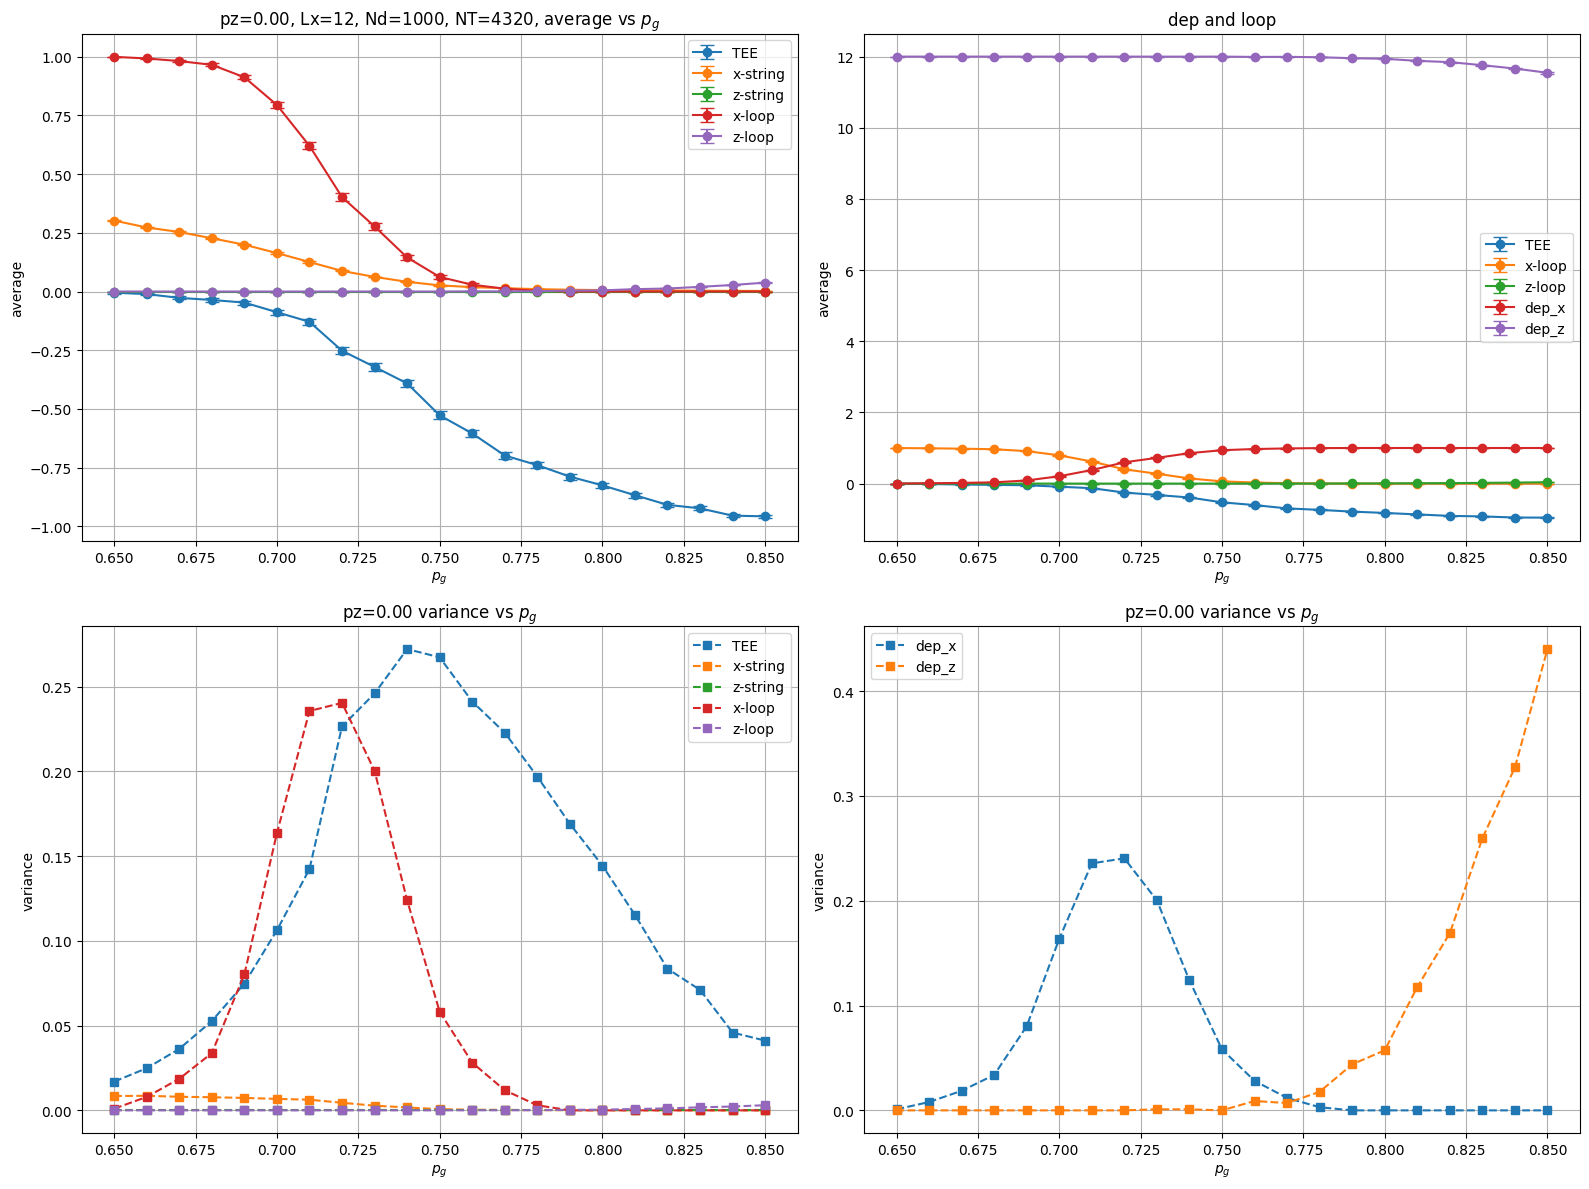

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# カラーマップ設定
cmap = plt.colormaps['gnuplot']

# ファイル読み込み
files = glob.glob("results_pz_0.0_Lx_12_Nd_1000_NT_4320.npz")
print("見つかったファイル:", files)

for file in files:
    match = re.search(
        r"pz_([0-9.]+)_Lx_(\d+)_Nd_(\d+)_NT_(\d+)", file
    )
    if match:
        pz = float(match.group(1))
        Lx = int(match.group(2))
        Nd = int(match.group(3))
        NT = int(match.group(4))
        print(f"{file} → Lx={Lx}, Nd={Nd}, NT={NT}, pz={pz}")

# プロット用
fig, ax = plt.subplots(2, 2, figsize=(16, 12))

for file in files:
    with np.load(file) as data:
        pg = data['pg']                      # ← 必ず最初に読み込む
        sort_idx = np.argsort(pg)           # ← 昇順インデックス
        pg = pg[sort_idx]                   # ← 並び替え
                
        TEE_ave = data['TEE_ave'][sort_idx]
        TEE_err = data['TEE_err'][sort_idx]
        TEE_var = data['TEE_var'][sort_idx]
        R2x_ave = data['R2x_ave'][sort_idx]
        R2x_err = data['R2x_err'][sort_idx]
        R2x_var = data['R2x_var'][sort_idx]
        R2z_ave = data['R2z_ave'][sort_idx]
        R2z_err = data['R2z_err'][sort_idx]
        R2z_var = data['R2z_var'][sort_idx]
        R2x_loop_ave = data['R2x_loop_ave'][sort_idx]
        R2x_loop_err = data['R2x_loop_err'][sort_idx]
        R2x_loop_var = data['R2x_loop_var'][sort_idx]
        R2z_loop_ave = data['R2z_loop_ave'][sort_idx]
        R2z_loop_err = data['R2z_loop_err'][sort_idx]
        R2z_loop_var = data['R2z_loop_var'][sort_idx]
        dep_x_ave = data['dep_x_ave'][sort_idx]
        dep_x_err = data['dep_x_err'][sort_idx]
        dep_x_var = data['dep_x_var'][sort_idx]
        dep_z_ave = data['dep_z_ave'][sort_idx]
        dep_z_err = data['dep_z_err'][sort_idx]
        dep_z_var = data['dep_z_var'][sort_idx]

    #label = f"px={px:.2f}"
    #label =f"ee"
    # 左グラフ：TEEと相関の平均＋誤差
    ax[0,0].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,0].errorbar(pg, R2x_ave, yerr=R2x_err, fmt='o-', capsize=5, label="x-string")
    ax[0,0].errorbar(pg, R2z_ave, yerr=R2z_err, fmt='o-', capsize=5, label="z-string")
    ax[0,0].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,0].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")

    # 右グラフ：分散
    ax[0,1].errorbar(pg, TEE_ave, yerr=TEE_err, fmt='o-', capsize=5, label="TEE")
    ax[0,1].errorbar(pg, R2x_loop_ave, yerr=R2x_loop_err, fmt='o-', capsize=5, label="x-loop")
    ax[0,1].errorbar(pg, R2z_loop_ave, yerr=R2z_loop_err, fmt='o-', capsize=5, label="z-loop")
    ax[0,1].errorbar(pg, dep_x_ave, yerr=dep_x_err, fmt='o-', capsize=5, label="dep_x")
    ax[0,1].errorbar(pg, dep_z_ave, yerr=dep_z_err, fmt='o-', capsize=5, label="dep_z")

    ax[1,0].plot(pg, TEE_var, 's--', label="TEE")    
    ax[1,0].plot(pg, R2x_var, 's--', label="x-string")
    ax[1,0].plot(pg, R2z_var, 's--', label="z-string")
    ax[1,0].plot(pg, R2x_loop_var, 's--', label="x-loop")
    ax[1,0].plot(pg, R2z_loop_var, 's--', label="z-loop")
    
    ax[1,1].plot(pg, dep_x_var, 's--', label="dep_x")
    ax[1,1].plot(pg, dep_z_var, 's--', label="dep_z")

    print(f"{file}: Lx= {Lx}")

# 描画設定
ax[0,0].set_xlabel('$p_g$')
ax[0,0].set_ylabel('average')
ax[0,0].set_title(f"pz={pz:.2f}, Lx={Lx}, Nd={Nd}, NT={NT}, average vs $p_g$")
ax[0,0].grid(True)
ax[0,0].legend()

ax[0,1].set_xlabel('$p_g$')
ax[0,1].set_ylabel('average')
ax[0,1].set_title("dep and loop")
ax[0,1].grid(True)
ax[0,1].legend()

ax[1,0].set_xlabel('$p_g$')
ax[1,0].set_ylabel('variance')
ax[1,0].set_title(f"pz={pz:.2f} variance vs $p_g$")
ax[1,0].grid(True)
ax[1,0].legend()

ax[1,1].set_xlabel('$p_g$')
ax[1,1].set_ylabel('variance')
ax[1,1].set_title(f"pz={pz:.2f} variance vs $p_g$")
ax[1,1].grid(True)
ax[1,1].legend()

plt.tight_layout()
plt.savefig(f"Lx_{Lx}_Nd_{Nd}_NT_{NT}_pz_{pz:.2f}_results.png", dpi=300, bbox_inches='tight')
plt.show()


In [17]:
import numpy as np

data = np.load("results_Lx_12_Nd_10_NT_1728_px_0.0.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['pg', 'TEE_ave', 'TEE_err', 'TEE_var', 'R2x_ave', 'R2x_err', 'R2x_var', 'R2z_ave', 'R2z_err', 'R2z_var', 'R2x_loop_ave', 'R2x_loop_err', 'R2x_loop_var', 'R2z_loop_ave', 'R2z_loop_err', 'R2z_loop_var']


In [16]:
import numpy as np

data = np.load("results_Lx_12_Nd_10_NT_1728_px_0.0.npz")
print(data['pg'])
print(data['R2x_ave'])
print(data['R2x_err'])
print(data['R2x_var'])
print(data['R2x_loop_ave'])
print(data['R2x_loop_err'])
print(data['R2x_loop_var'])
data.close()

[0.7  0.72 0.74 0.76 0.78 0.8  0.82 0.84 0.86 0.88 0.9  0.71 0.73 0.75
 0.77 0.79 0.81 0.83 0.85 0.87 0.89]
[0.0030303  0.00227273 0.         0.00227273 0.00075758 0.00075758
 0.00378788 0.         0.00151515 0.00151515 0.00606061 0.00151515
 0.00075758 0.00075758 0.00151515 0.         0.00227273 0.00151515
 0.00075758 0.00151515 0.00075758]
[0.00167506 0.00115722 0.         0.00115722 0.00075758 0.00075758
 0.00232817 0.         0.0010101  0.00151515 0.00387937 0.0010101
 0.00075758 0.00075758 0.0010101  0.         0.00161695 0.0010101
 0.00075758 0.00151515 0.00075758]
[2.52525253e-05 1.20523416e-05 0.00000000e+00 1.20523416e-05
 5.16528926e-06 5.16528926e-06 4.87832874e-05 0.00000000e+00
 9.18273646e-06 2.06611570e-05 1.35445363e-04 9.18273646e-06
 5.16528926e-06 5.16528926e-06 9.18273646e-06 0.00000000e+00
 2.35307622e-05 9.18273646e-06 5.16528926e-06 2.06611570e-05
 5.16528926e-06]
[0.         0.         0.00833333 0.         0.00833333 0.05833333
 0.05       0.1        0.11666667

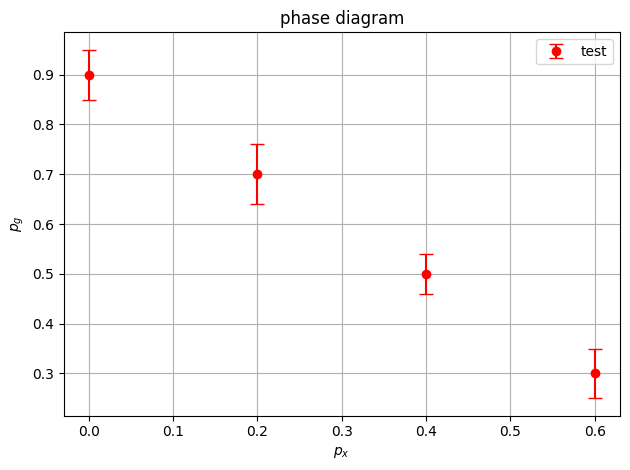

In [71]:
px = np.array([0.0, 0.2, 0.4, 0.6])
pg = np.array([0.9, 0.7, 0.5, 0.3])
pg_err = np.array([0.05, 0.06, 0.04, 0.05])  # 幅（例）

plt.errorbar(px, pg, yerr=pg_err, fmt='o', color='red', capsize=5, label="test")
plt.xlabel(r'$p_x$')
plt.ylabel(r'$p_g$')
plt.title("phase diagram")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

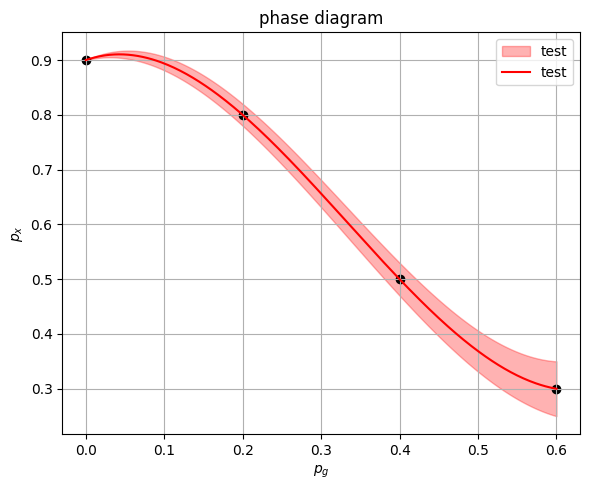

In [83]:
from scipy.interpolate import make_interp_spline

px = np.array([0.0, 0.2, 0.4, 0.6])
pg = np.array([0.9, 0.8, 0.5, 0.3])
pg_err = np.array([0.00, 0.02, 0.03, 0.05])  # 幅（例）

# 中央点と誤差
pg_upper = pg + pg_err
pg_lower = pg - pg_err

# 補間（なめらかな曲線に）
px_smooth = np.linspace(px.min(), px.max(), 300)
spline_mid = make_interp_spline(px, pg, k=3)
spline_upper = make_interp_spline(px, pg_upper, k=3)
spline_lower = make_interp_spline(px, pg_lower, k=3)

pg_smooth = spline_mid(px_smooth)
pg_smooth_upper = spline_upper(px_smooth)
pg_smooth_lower = spline_lower(px_smooth)

# 描画
plt.figure(figsize=(6, 5))
plt.fill_between(px_smooth, pg_smooth_lower, pg_smooth_upper, color='red', alpha=0.3, label='test')
plt.plot(px_smooth, pg_smooth, color='red', label='test')
plt.scatter(px, pg, color='black')
plt.xlabel(r'$p_g$')
plt.ylabel(r'$p_x$')
plt.title("phase diagram")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()